In [17]:
import requests
import pandas as pd
import folium

status_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_status.json"
status_data = requests.get(status_url).json()

stations = pd.json_normalize(status_data['data']['stations'])
stations.head()


,station_id,num_bikes_available,num_ebikes_available,vehicle_types_available,num_bikes_disabled,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,eightd_has_available_keys,is_charging
0,3,4,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,15,0,1,1,1,1772344367,False,False
1,15,14,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,1,0,1,1,1,1772340669,False,False
2,17,8,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,19,0,1,1,1,1772346488,False,False
3,19,11,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,16,0,1,1,1,1772344269,False,False
4,24,2,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,9,0,1,1,1,1772269897,False,False


In [18]:
stations.shape
stations.columns


Index(['station_id', 'num_bikes_available', 'num_ebikes_available',
       'vehicle_types_available', 'num_bikes_disabled', 'num_docks_available',
       'num_docks_disabled', 'is_installed', 'is_renting', 'is_returning',
       'last_reported', 'eightd_has_available_keys', 'is_charging'],
      dtype='object')

In [19]:
stations[['num_bikes_available','num_docks_available']].describe()


,num_bikes_available,num_docks_available
count,240.000000,240.000000
mean,9.354167,13.804167
std,6.264363,7.363200
min,0.000000,0.000000
25%,5.000000,9.000000
50%,8.000000,13.000000
75%,13.000000,17.000000
max,45.000000,46.000000


<Axes: >

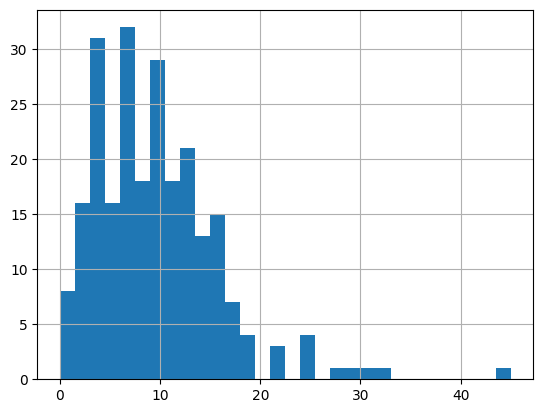

In [20]:
stations['num_bikes_available'].hist(bins=30)


In [21]:
stations.nlargest(10, 'num_bikes_available')[['station_id','num_bikes_available']]


,station_id,num_bikes_available
5,25,45
66,214,32
144,582,31
37,111,29
9,35,28
27,83,24
76,290,24
99,388,24
156,647,24
131,541,22


In [22]:
stations['calculated_utilization'] = stations['num_bikes_available'] / (
    stations['num_bikes_available'] + stations['num_docks_available']
)
stations['calculated_utilization'].describe()


count    239.000000
mean       0.405470
std        0.219196
min        0.000000
25%        0.226540
50%        0.400000
75%        0.538462
max        0.941176
Name: calculated_utilization, dtype: float64

Checking Station Utilization Rate and Overlay on Map

In [23]:
# URLs
info_url   = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"

# Load JSON
status_data = requests.get(status_url).json()
info_data   = requests.get(info_url).json()

# Normalize into DataFrames
status_df = pd.json_normalize(status_data['data']['stations'])
info_df   = pd.json_normalize(info_data['data']['stations'])


In [24]:
stations_merged = pd.merge(info_df, status_df, on="station_id")
stations_merged.head()


,station_id,external_id,name,short_name,lat,lon,rental_methods,capacity,electric_bike_surcharge_waiver,is_charging_x,...,vehicle_types_available,num_bikes_disabled,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,eightd_has_available_keys,is_charging_y
0,3,0b0fe114-08f3-11e7-a1cb-3863bb33a4e4,Clark / Ontario,6003,45.510588,-73.566846,"[CREDITCARD, KEY]",19,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,15,0,1,1,1,1772344367,False,False
1,15,0b0ffa68-08f3-11e7-a1cb-3863bb33a4e4,Métro Berri-UQAM (St-Denis / de Maisonneuve),6015,45.514252,-73.561502,"[CREDITCARD, KEY]",15,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,1,0,1,1,1,1772340669,False,False
2,17,0b0ffd3a-08f3-11e7-a1cb-3863bb33a4e4,Marché St-Jacques (Atateken),6017,45.520666,-73.563915,"[CREDITCARD, KEY]",27,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,19,0,1,1,1,1772346488,False,False
3,19,0b100002-08f3-11e7-a1cb-3863bb33a4e4,Métro Sherbrooke (de Rigaud / Berri),6019,45.518143,-73.568004,"[CREDITCARD, KEY]",27,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,16,0,1,1,1,1772344269,False,False
4,24,0b1006f9-08f3-11e7-a1cb-3863bb33a4e4,Notre-Dame / St-Gabriel,6025,45.507118,-73.555049,"[CREDITCARD, KEY]",11,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,9,0,1,1,1,1772269897,False,False


In [25]:
stations_merged['capacity'] = stations_merged['capacity'].astype(int)
stations_merged['utilization'] = stations_merged['num_bikes_available'] / stations_merged['capacity']


In [26]:

# Center map on Montréal
m = folium.Map(location=[45.5017, -73.5673], zoom_start=12)

# Add stations
for _, row in stations_merged.iterrows():
    popup_text = f"""
    <b>{row['name']}</b><br>
    Bikes Available: {row['num_bikes_available']}<br>
    Docks Available: {row['num_docks_available']}<br>
    Utilization: {row['utilization']:.0%}
    """
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color="green" if row['utilization'] < 0.5 else "red",
        fill=True,
        fill_opacity=0.7,
        popup=popup_text
    ).add_to(m)

m.save("bixi_map_utilization.html")


Cross Check between both APIs (station status and station capacity)

In [27]:
stations_merged['calculated_capacity'] = stations_merged['num_bikes_available'] + stations_merged['num_docks_available']
top_capacity = stations_merged.nlargest(10, 'calculated_capacity')[['station_id','name','calculated_capacity']]
print(top_capacity)


    station_id                                               name  \
5           25              de la Commune / Place Jacques-Cartier   
144        582                       Jeanne-Mance / René-Lévesque   
220       1058                             de la Commune / McGill   
148        608                              McTavish / Sherbrooke   
203        952            Métro Viau (Pierre-de-Coubertin / Viau)   
18          62              Métro Peel (de Maisonneuve / Stanley)   
99         388    Métro Pie-IX (Pierre-de-Coubertin / Desjardins)   
9           35                         de la Commune / St-Sulpice   
66         214  Parc Jeanne-Mance (monument sir George-Étienne...   
23          77                                  Peel / Notre-Dame   

     calculated_capacity  
5                     80  
144                   58  
220                   56  
148                   54  
203                   52  
18                    49  
99                    48  
9                     47

<Axes: >

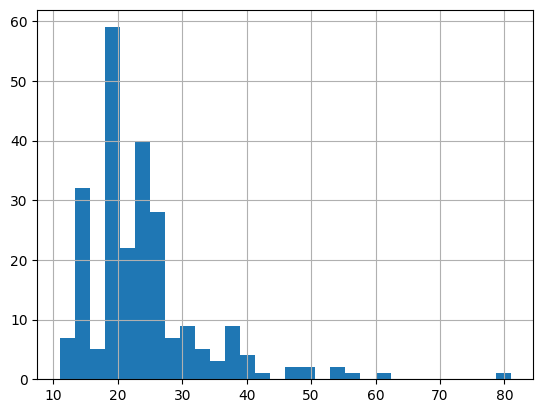

In [28]:
stations_merged['capacity'].hist(bins=30)


In [34]:
stations_merged[['name','capacity','calculated_capacity']].sort_values('capacity', ascending=False).head(20)


,name,capacity,calculated_capacity
5,de la Commune / Place Jacques-Cartier,81,80
144,Jeanne-Mance / René-Lévesque,61,58
220,de la Commune / McGill,56,56
203,Métro Viau (Pierre-de-Coubertin / Viau),55,52
148,McTavish / Sherbrooke,54,54
18,Métro Peel (de Maisonneuve / Stanley),49,49
99,Métro Pie-IX (Pierre-de-Coubertin / Desjardins),49,48
9,de la Commune / St-Sulpice,47,47
66,Parc Jeanne-Mance (monument sir George-Étienne...,47,47
23,Peel / Notre-Dame,43,42


In [35]:
stations_merged[['name','capacity','calculated_capacity']].sort_values('capacity', ascending=False).tail(10)


,name,capacity,calculated_capacity
229,Gordon / Wellington,15,14
81,de l'Hôtel-de-Ville / Rachel,14,14
167,BIXI K5,14,14
103,de la Cote-Ste-Catherine / Davaar,11,11
56,du Mont-Royal / Christophe-Colomb,11,11
51,St-Hubert / du Mont-Royal,11,11
10,du Mont-Royal / St-André,11,11
4,Notre-Dame / St-Gabriel,11,11
24,Métro Lucien-L'Allier (Lucien l'Allier / Argyle),11,11
44,Métro Fabre (Fabre / Jean-Talon),11,10


In [30]:
stations_merged.head()

,station_id,external_id,name,short_name,lat,lon,rental_methods,capacity,electric_bike_surcharge_waiver,is_charging_x,...,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,eightd_has_available_keys,is_charging_y,utilization,calculated_capacity
0,3,0b0fe114-08f3-11e7-a1cb-3863bb33a4e4,Clark / Ontario,6003,45.510588,-73.566846,"[CREDITCARD, KEY]",19,False,False,...,15,0,1,1,1,1772344367,False,False,0.210526,19
1,15,0b0ffa68-08f3-11e7-a1cb-3863bb33a4e4,Métro Berri-UQAM (St-Denis / de Maisonneuve),6015,45.514252,-73.561502,"[CREDITCARD, KEY]",15,False,False,...,1,0,1,1,1,1772340669,False,False,0.933333,15
2,17,0b0ffd3a-08f3-11e7-a1cb-3863bb33a4e4,Marché St-Jacques (Atateken),6017,45.520666,-73.563915,"[CREDITCARD, KEY]",27,False,False,...,19,0,1,1,1,1772346488,False,False,0.296296,27
3,19,0b100002-08f3-11e7-a1cb-3863bb33a4e4,Métro Sherbrooke (de Rigaud / Berri),6019,45.518143,-73.568004,"[CREDITCARD, KEY]",27,False,False,...,16,0,1,1,1,1772344269,False,False,0.407407,27
4,24,0b1006f9-08f3-11e7-a1cb-3863bb33a4e4,Notre-Dame / St-Gabriel,6025,45.507118,-73.555049,"[CREDITCARD, KEY]",11,False,False,...,9,0,1,1,1,1772269897,False,False,0.181818,11


Discrepancy exists between the station status bikes available + docks available

To use station capacity data directly

In [31]:
for _, row in stations_merged.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['capacity'] / 10,  # scale marker size
        color="blue",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['name']}<br>Total Capacity: {row['capacity']}"
    ).add_to(m)


In [33]:
top20_utilization = stations_merged.nlargest(20, 'utilization')[['station_id','name','capacity','num_bikes_available','num_docks_available','utilization']]
print(top20_utilization)

    station_id                                               name  capacity  \
1           15       Métro Berri-UQAM (St-Denis / de Maisonneuve)        15   
61         206                                 Boyer / Jean-Talon        15   
175        806      Parc Beaubien Outremont (Stuart / St-Viateur)        15   
154        645                               Ste-Claire / Baldwin        23   
22          76                                    Duke / Nazareth        19   
141        572                                Melrose / de Verdun        19   
177        822  Place Émilie-Gamelin (St-Hubert / de Maisonneuve)        19   
131        541                                Fullum / Marie-Anne        26   
192        889             Parc St-Gabriel (Grand Trunk / Ropery)        19   
235       1146                            de Maisonneuve / Mackay        19   
37         111                         de Maisonneuve / de Bleury        36   
12          47                                 Garni

In [36]:
bot10_utilization = stations_merged.nsmallest(10, 'utilization')[['station_id','name','capacity','num_bikes_available','num_docks_available','utilization']]
print(bot10_utilization)

    station_id                                               name  capacity  \
10          37                           du Mont-Royal / St-André        11   
30          97                            de Maisonneuve / Fullum        18   
51         157                          St-Hubert / du Mont-Royal        11   
56         169                  du Mont-Royal / Christophe-Colomb        11   
77         291                        de la Montagne / Notre-Dame        23   
172        794            Marché Jean-Talon (Casgrain / Shamrock)        29   
126        527  Métro Université de Montréal (Édouard-Montpeti...        26   
197        916                              de Bordeaux / Gilford        23   
18          62              Métro Peel (de Maisonneuve / Stanley)        49   
6           26                   de Maisonneuve / Mansfield (sud)        27   

     num_bikes_available  num_docks_available  utilization  
10                     0                   11     0.000000  
30      